In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import IncrementalPCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

df_country = pd.read_csv("/content/Country-data.csv")
df_country.head()
round(100*(df_country.isnull().sum())/len(df_country), 2)

,0
country,0.0
child_mort,0.0
exports,0.0
health,0.0
imports,0.0
income,0.0
inflation,0.0
life_expec,0.0
total_fer,0.0
gdpp,0.0


In [6]:
df_country.loc[df_country.duplicated()]
cat_col = df_country.select_dtypes(include = ['object']).columns

print(cat_col)

num_col = df_country.select_dtypes(exclude = ['object']).columns

print(num_col)

Index(['country'], dtype='object')
Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


<Axes: >

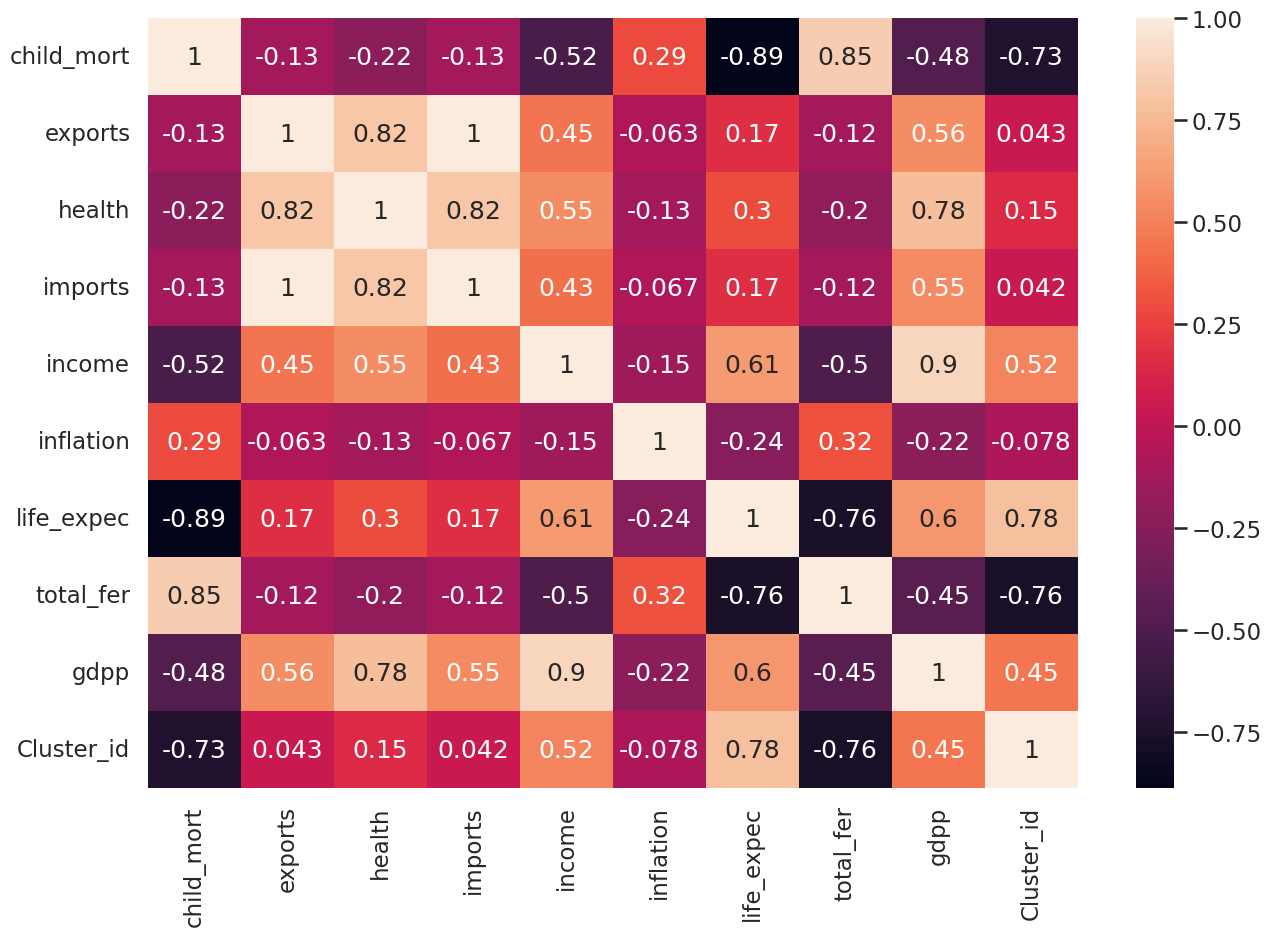

In [54]:
#heatmap
plt.figure(figsize = (15,10))
sns.heatmap(df_country.corr(), annot = True)

In [ ]:
sns.pairplot(df_country)

In [12]:
df_country['exports'] = df_country['exports'] * df_country['gdpp']/100
df_country['imports'] = df_country['imports'] * df_country['gdpp']/100
df_country['health'] = df_country['health'] * df_country['gdpp']/100

df = df_country.copy()

In [13]:
country = df.pop('country')

In [14]:
scaler = StandardScaler()

df_scaled_arr = scaler.fit_transform(df)

In [15]:
df_scaled = pd.DataFrame(df_scaled_arr)
df_scaled.columns = num_col
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.147456,-0.256344,-0.146987,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.147337,-0.255885,-0.146731,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.147244,-0.255965,-0.146773,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,-0.147285,-0.256216,-0.146842,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,-0.142305,-0.245114,-0.138739,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [16]:
pca = PCA(svd_solver = 'randomized', random_state = 42)
#fitting pca to the scaled dataframe
pca.fit(df_scaled)
#Variance Ratio
pca.explained_variance_ratio_

df_pca_att = pd.DataFrame({'Attribute':df_scaled.columns, 'PC_1':pca.components_[0],
                                                          'PC_2':pca.components_[1],
                                                          'PC_3':pca.components_[2] })
df_pca_att

,Attribute,PC_1,PC_2,PC_3
0,child_mort,-0.322435,0.417288,-0.069573
1,exports,0.321744,0.435200,-0.076098
2,health,0.362138,0.340624,-0.042002
3,imports,0.319377,0.434538,-0.086480
4,income,0.388771,-0.038120,0.221466
5,inflation,-0.140191,0.182076,0.948170
6,life_expec,0.346481,-0.363455,0.152621
7,total_fer,-0.307213,0.402560,0.000745
8,gdpp,0.417307,0.053528,0.093590


In [17]:
round(df_scaled.describe(percentiles=[0.15,0.35,0.55,0.75,0.95]),2) # creating percentile to check outliers

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-0.15,-0.26,-0.15,-0.86,-1.14,-4.34,-1.19,-0.70
15%,-0.83,-0.15,-0.26,-0.15,-0.79,-0.64,-1.15,-0.93,-0.67
35%,-0.66,-0.15,-0.26,-0.15,-0.59,-0.46,-0.23,-0.64,-0.55
50%,-0.47,-0.15,-0.26,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
55%,-0.35,-0.15,-0.25,-0.15,-0.23,-0.17,0.38,-0.23,-0.38
75%,0.59,-0.14,-0.24,-0.13,0.29,0.28,0.70,0.62,0.06
95%,1.93,0.27,0.96,0.34,1.62,1.24,1.22,1.93,1.95


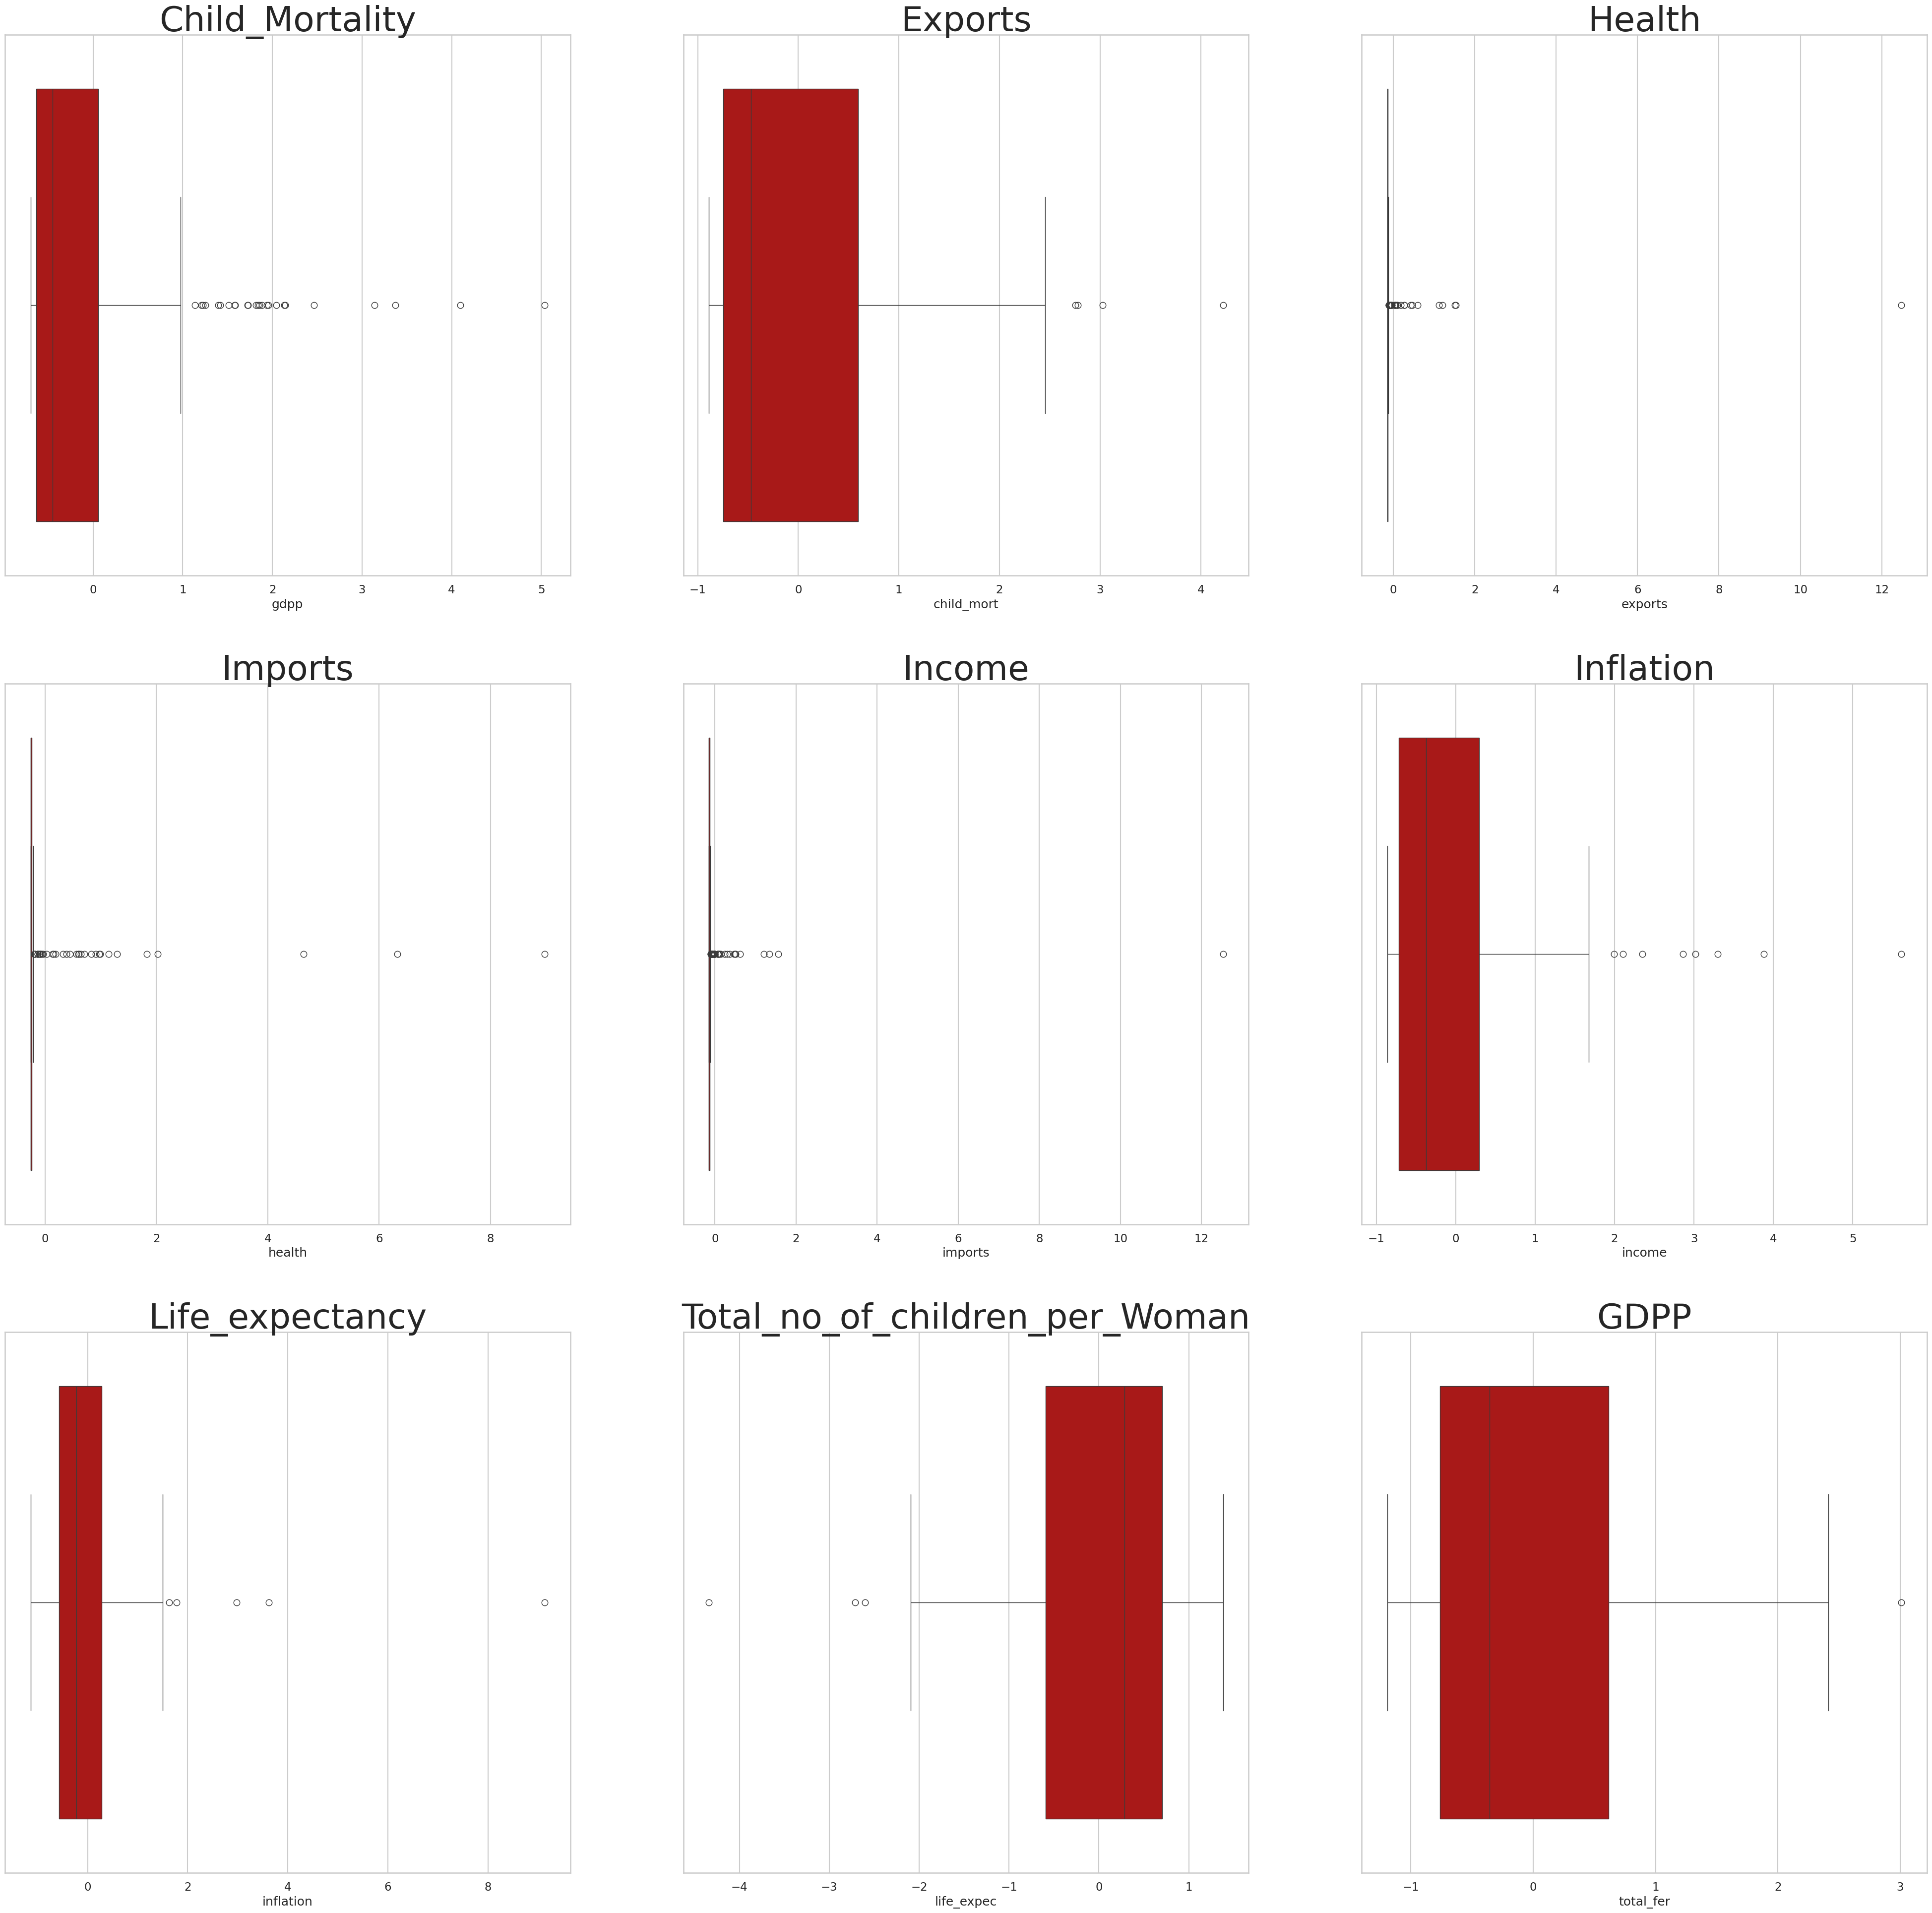

In [18]:
# Setting size of figure, context and gridlines

plt.figure(figsize=(50,150))
plt.tight_layout()  #to fit plots within figure cleanly
sns.set_style('whitegrid')
sns.set_context('talk')

# Title names for the columns in the dataset

col={0:'Child_Mortality',1:'Exports',2:'Health',3:'Imports',4:'Income',5:'Inflation',
     6:'Life_expectancy',7:'Total_no_of_children_per_Woman',8:'GDPP'}

# Visualising the outliers with boxplot for all the variables

for i in range(9):
    plt.subplot(9,3,i+1)
    plt.title(col[i],fontsize=50)
    sns.boxplot(x=df_scaled.columns[i-1],data=df_scaled,palette='gist_heat',orient='v')  # using boxplot



In [19]:
 #Building the dataframe using Incremental PCA for better efficiency.

inc_pca = IncrementalPCA(n_components=5)

#fitting scaled_df on incremental PCA


df_inc_pca = inc_pca.fit_transform(df_scaled)

df_inc_pca = pd.DataFrame(df_inc_pca, columns = ['PC_1','PC_2','PC_3','PC_4','PC_5'])

df_inc_pca.head()

,PC_1,PC_2,PC_3,PC_4,PC_5
0,-2.369574,1.700240,-0.392913,0.500420,0.188538
1,0.170985,-1.090922,-0.254308,-0.815335,0.008727
2,-0.245200,-0.461146,0.811643,-0.582408,0.323965
3,-2.534706,2.155072,0.850696,0.713157,0.317229
4,0.563002,-1.085921,-0.362891,-0.245699,0.063558


In [20]:
df_pca_final = pd.concat([country,df_inc_pca], axis = 1)
df_pca_final.head()

,country,PC_1,PC_2,PC_3,PC_4,PC_5
0,Afghanistan,-2.369574,1.700240,-0.392913,0.500420,0.188538
1,Albania,0.170985,-1.090922,-0.254308,-0.815335,0.008727
2,Algeria,-0.245200,-0.461146,0.811643,-0.582408,0.323965
3,Angola,-2.534706,2.155072,0.850696,0.713157,0.317229
4,Antigua and Barbuda,0.563002,-1.085921,-0.362891,-0.245699,0.063558


In [22]:
# Silhouette analysis


num_clusters = [2,3,4,5,6,7,8,9]                                        # selecting range of clusters
for i in num_clusters:                                                # For loop
    kmeans=KMeans(n_clusters=i,max_iter=50)                            # Using iteration 50 for finding Kmeans
    kmeans.fit(df_inc_pca)                                             # fitting the kmeans
    cluster_label=kmeans.labels_                                        # saving the labels in a cluster_label list

    sil_score = silhouette_score(df_inc_pca,cluster_label)        # finding the silhouette score

    # Printing for all number of clusters of range(2,10) for silhouette score

    print("For no. of cluster={0},silhouette score is {1}".format(i,sil_score))

For no. of cluster=2,silhouette score is 0.4298648856935454
For no. of cluster=3,silhouette score is 0.45169680061166617
For no. of cluster=4,silhouette score is 0.40792967151734727
For no. of cluster=5,silhouette score is 0.32590008676344456
For no. of cluster=6,silhouette score is 0.4500939239434925
For no. of cluster=7,silhouette score is 0.29288339090247495
For no. of cluster=8,silhouette score is 0.3314753318152732
For no. of cluster=9,silhouette score is 0.33262942946773


In [23]:
#Final model n_clusters = 4

kmeans=KMeans(n_clusters=4,max_iter=50,random_state=42)         # k=4 and iteration=50
kmeans.fit(df_inc_pca)

KMeans(max_iter=50, n_clusters=4, random_state=42)

In [24]:
kmeans.labels_

array([0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 2, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 2, 0,
       0, 2, 2, 1, 2, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 0, 0,
       2, 2, 0, 3, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 2,
       0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 2, 2,
       0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 0], dtype=int32)

In [25]:
# Uploading the cluster labels in our original dataset

df_country['Cluster_id'] = kmeans.labels_
df_country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_id
0,Afghanistan,90.2,1.691124e+03,1.281872e+03,7.593146e+03,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,1.915702e+06,4.481374e+05,3.325111e+06,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,3.406715e+06,3.699480e+05,2.785699e+06,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,2.740389e+06,1.253629e+05,1.887041e+06,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,8.262108e+07,1.094956e+07,1.069534e+08,19100,1.44,76.8,2.13,12200,2


In [26]:
df_country.set_index('country',inplace = True)

In [27]:
df_country.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_id
country,,,,,,,,,,
Afghanistan,90.2,1.691124e+03,1.281872e+03,7.593146e+03,1610,9.44,56.2,5.82,553,0
Albania,16.6,1.915702e+06,4.481374e+05,3.325111e+06,9930,4.49,76.3,1.65,4090,2
Algeria,27.3,3.406715e+06,3.699480e+05,2.785699e+06,12900,16.10,76.5,2.89,4460,2
Angola,119.0,2.740389e+06,1.253629e+05,1.887041e+06,5900,22.40,60.1,6.16,3530,0
Antigua and Barbuda,10.3,8.262108e+07,1.094956e+07,1.069534e+08,19100,1.44,76.8,2.13,12200,2


<Axes: title={'center': 'Cluster level vs GDPP per capita'}, xlabel='Cluster_id', ylabel='gdpp'>

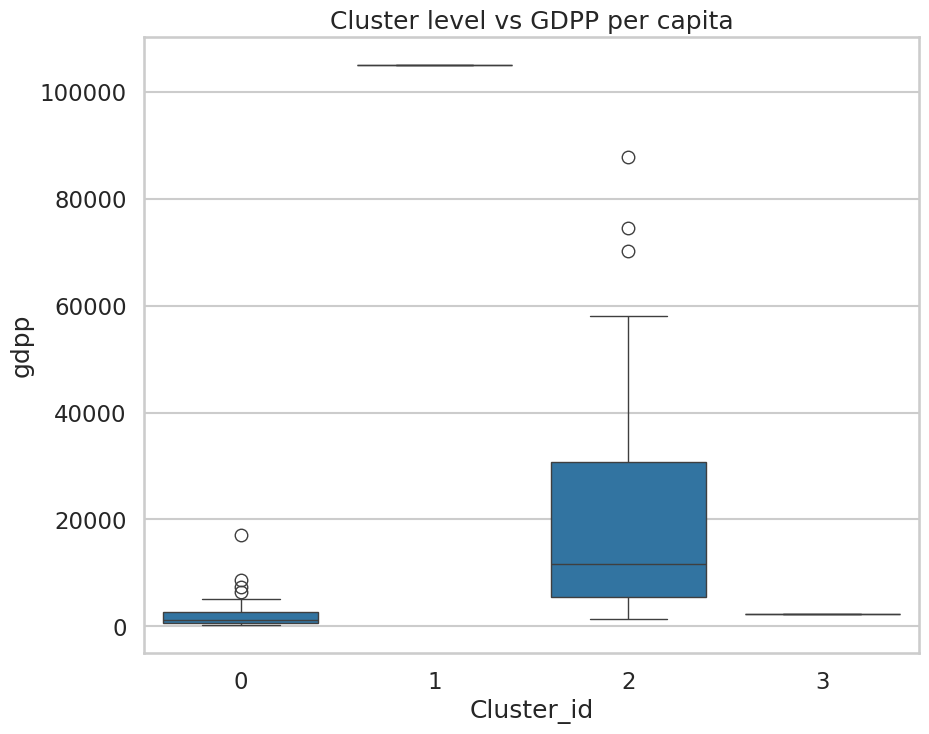

In [28]:
# Visualising the distribution of the cluster labels for column 'gdpp'

plt.figure(figsize=(10,8))
plt.title('Cluster level vs GDPP per capita')
sns.boxplot(x = 'Cluster_id',y = 'gdpp',data = df_country)

In [29]:
# Points to be concluded from above boxplot - gdpp(The GDP per capita) visualization:

#Cluster label 0 : Most of the countries in this boxplot are having little high gdpp than the very lowest gdpp group
#Cluster label 1 : Having very low gdpp than all the other cluster labels
#Cluster label 2 : Having highest gdpp
#Cluster label 3 : Having high gdpp with some outliers

<Axes: title={'center': 'Cluster level vs Child Mortality'}, xlabel='Cluster_id', ylabel='child_mort'>

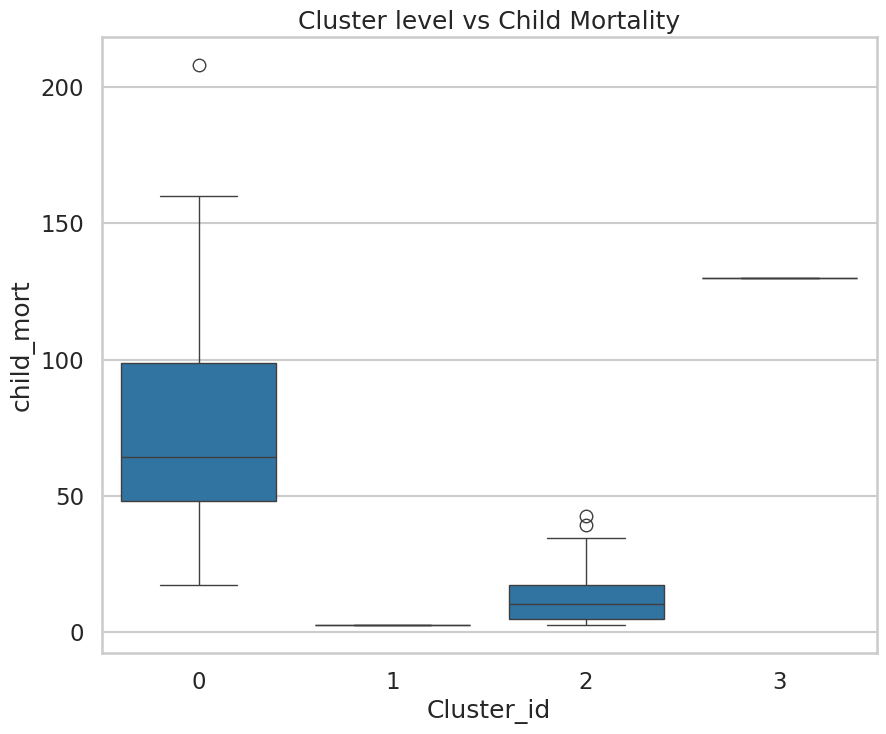

In [30]:
# Visualising the distribution of the cluster labels for column 'child_mort' using boxplot

plt.figure(figsize=(10,8))                    # setting figure size
plt.title('Cluster level vs Child Mortality') # Setting the title

sns.boxplot(x='Cluster_id',y='child_mort',data=df_country)  # Using boxplot

<Axes: title={'center': 'Cluster level vs Income'}, xlabel='Cluster_id', ylabel='income'>

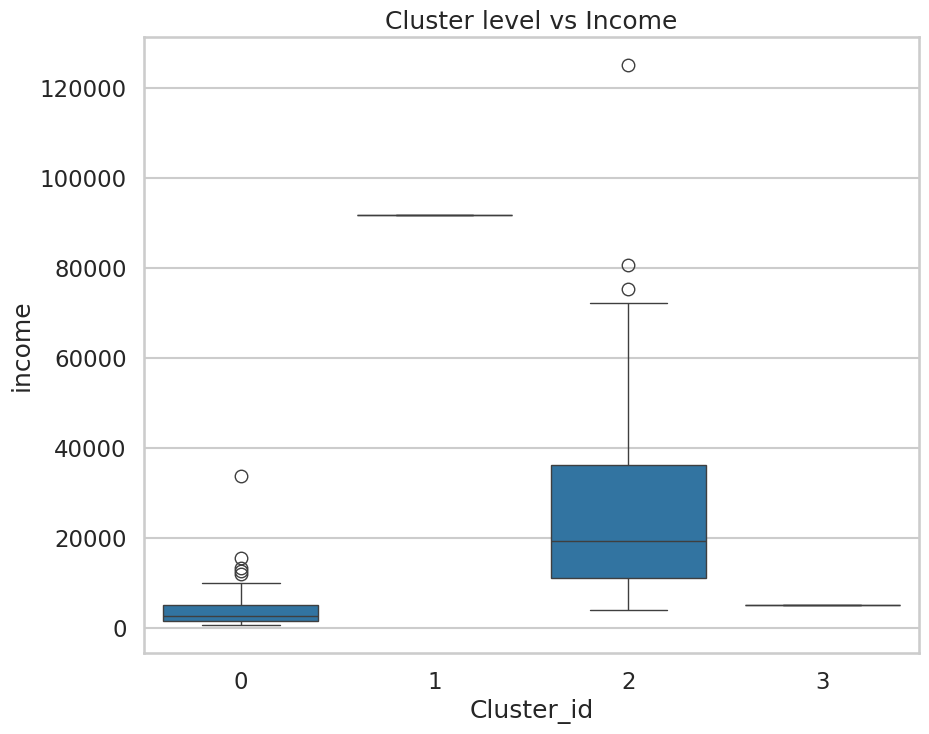

In [31]:
# Visualising the distribution of the cluster labels for column 'income'

plt.figure(figsize=(10,8))
plt.title('Cluster level vs Income')
sns.boxplot(x='Cluster_id',y='income',data=df_country)

In [32]:
df_pca_final['Cluster_ID'] = kmeans.labels_
df_pca_final.set_index('country',inplace = True)
df_pca_final.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,Cluster_ID
country,,,,,,
Afghanistan,-2.369574,1.700240,-0.392913,0.500420,0.188538,0
Albania,0.170985,-1.090922,-0.254308,-0.815335,0.008727,2
Algeria,-0.245200,-0.461146,0.811643,-0.582408,0.323965,2
Angola,-2.534706,2.155072,0.850696,0.713157,0.317229,0
Antigua and Barbuda,0.563002,-1.085921,-0.362891,-0.245699,0.063558,2


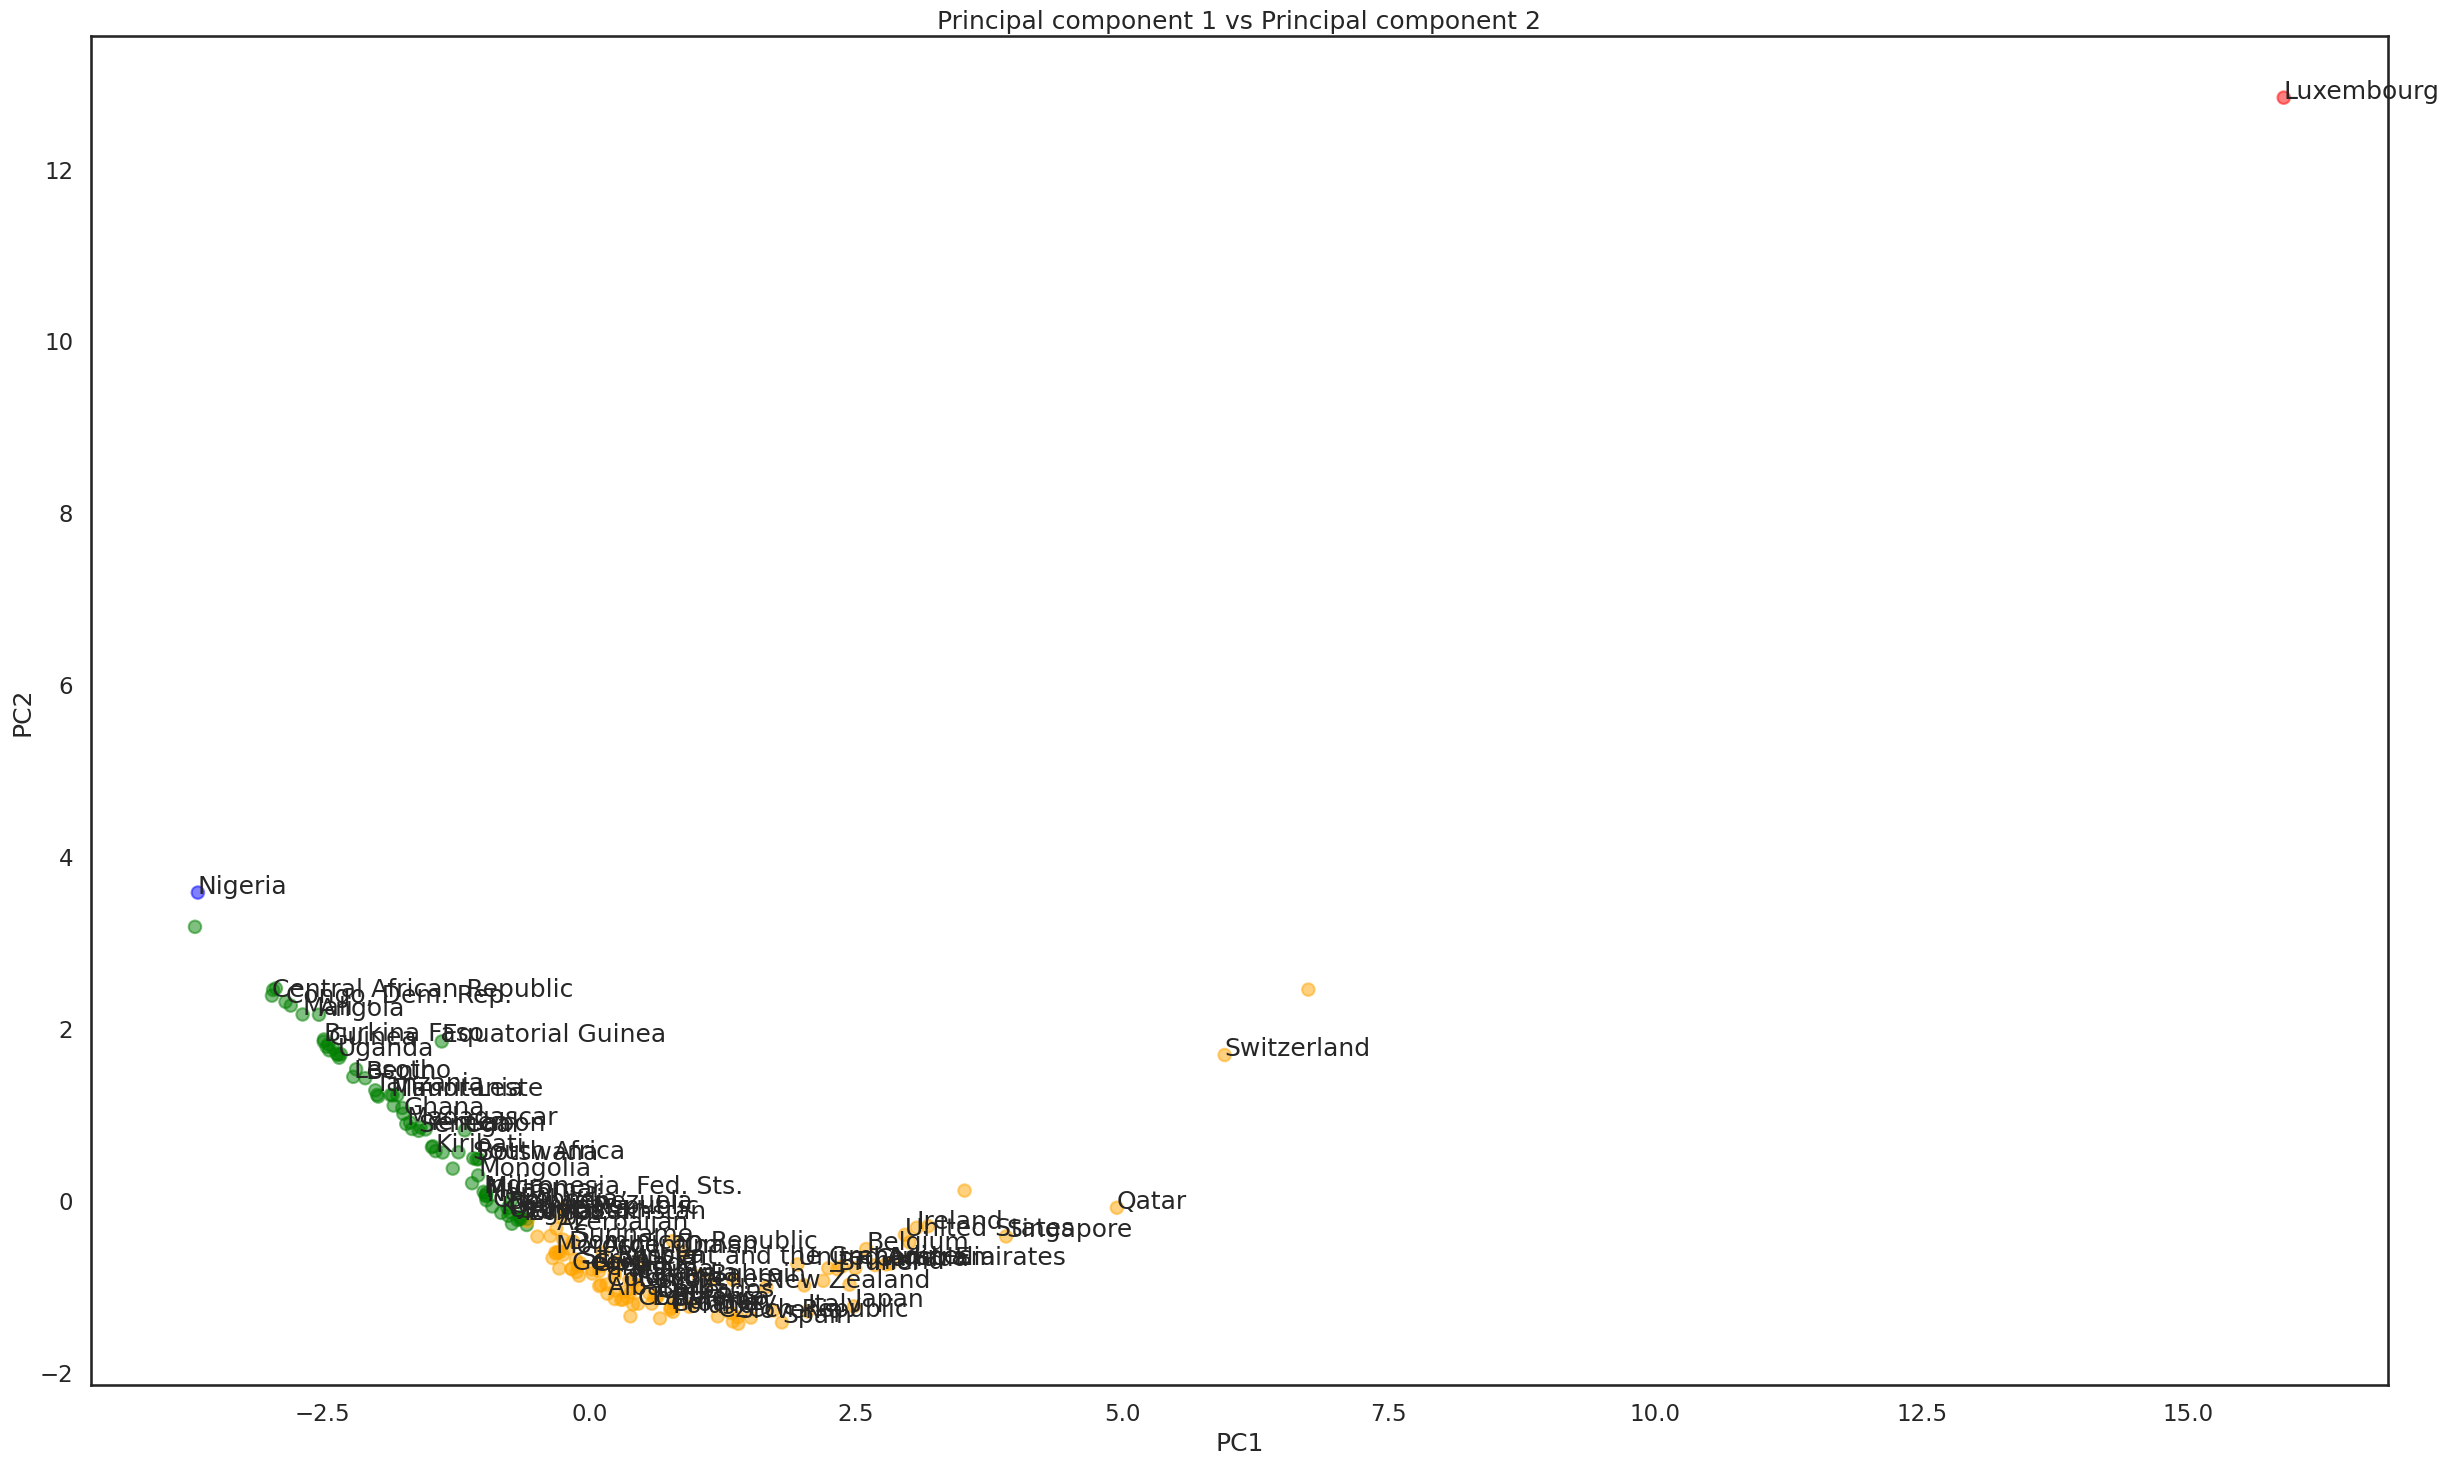

In [33]:

# Visualising the clusters formed by choosing first two pricipal components(on X-Y axes)
%matplotlib inline
sns.set_style('white')
sns.set_context('talk')

fig = plt.figure(figsize = (25,15))   # setting the figure size

# setting title

plt.title("Principal component 1 vs Principal component 2")

# Plotting a scatter plot

plt.scatter(df_pca_final['PC_1'] , df_pca_final['PC_2'] ,
            c = df_pca_final.Cluster_ID.map({0:'green',1:'red',2:'orange',3:'blue'}), alpha = 0.5)

# labeling different cluster points with country names
for i, txt in enumerate(df_pca_final.index):
    if i%2:
        plt.annotate(txt, (df_pca_final.PC_1[i],df_pca_final.PC_2[i]))

# labeling the axes

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()   # changing the layout
plt.show()           # Showing the plot

In [34]:
#As we can see from first two principal components(PC1 & PC2), the PC1 is in the direction where the countries need of least help. We are choosing PC1 because it has maximum percentage of variance explained.

#We can see that countries like 'Singapore' and 'Luxembourg' are having high PC1 which means they are doing well, where on other hand countries like 'Nigeria', 'Burkina Faso', Equatorial Guniea and close to them requires urgent need of aid.

#red colored countries are in dire need of help

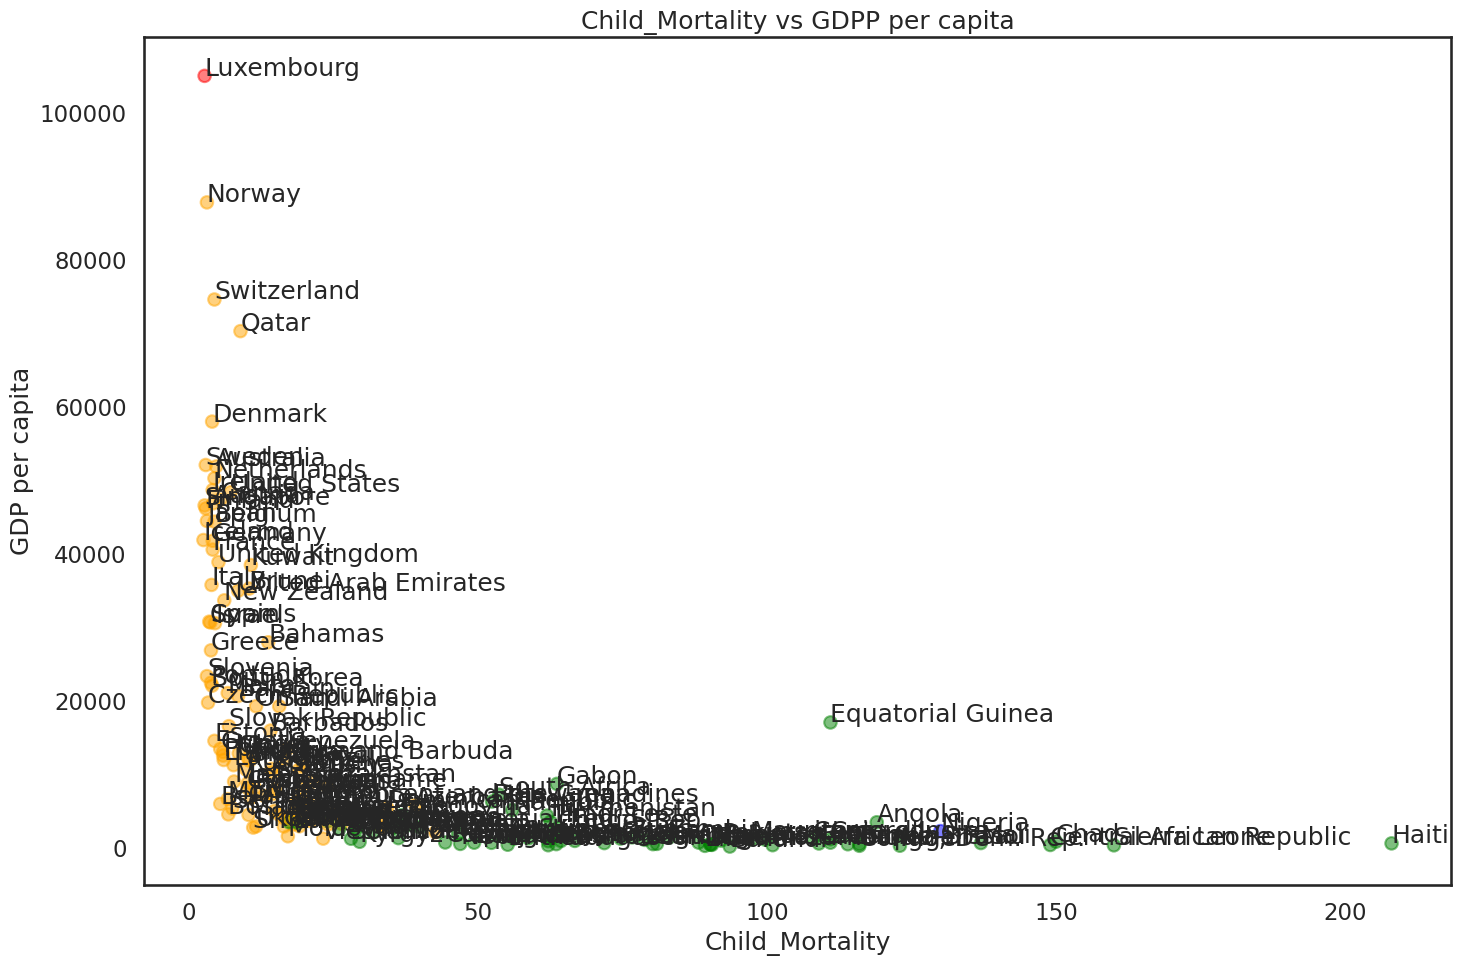

In [35]:
# Visualising the clusters formed with origibal varaibles(on X-Y axes)

%matplotlib inline
fig = plt.figure(figsize = (15,10))   # setting the figure size

# Plotting a scatter plot

plt.scatter(df_country['child_mort'], df_country['gdpp'],
            c = df_country.Cluster_id.map({0:'green',1:'red',2:'orange',3:'blue'}), alpha = 0.5)

# labeling different cluster points with country names

for i, txt in enumerate(df_country.index):
    plt.annotate(txt, (df_country.child_mort[i],df_country.gdpp[i]))

# labeling the axes and title

plt.title('Child_Mortality vs GDPP per capita')
plt.xlabel('Child_Mortality')
plt.ylabel('GDP per capita')

plt.tight_layout()  # changing the layout

plt.show()           # Showing the plot

In [36]:
#From the above scatter plot, Two points we can conclude :

#Country "Haiti","Central African Republic", "Chad" is in dire need of aid
#Country "Luxembourg" is having good gdp and less child mortality rate
#We must also keep in mind that countries like Angola, Chad , Central African Republic are war-torn and political instable. They would require urgent help for better healthcare

#red colored countries are in dire need of help

In [37]:
# Finding the countries with cluster label=1

Country_help = pd.DataFrame(df_country[df_country['Cluster_id'] == 1].index)

print(Country_help.shape)

final_country_list = list(Country_help['country'])

# Finding the countries with cluster label=2

Country_nohelp = pd.DataFrame(df_country[df_country['Cluster_id'] == 2].index)

Country_nohelp.shape

(1, 1)


(98, 1)

In [38]:
# Finding the countries with cluster label=0

Country_maybe_help = pd.DataFrame(df_country[df_country['Cluster_id'] == 3].index)

Country_maybe_help.shape

(1, 1)

In [39]:
#48 countries are in dire need of help
#1 country (Luxembourg) needs no help
#30 countries may need some help. Focus should be on countries with higher child mortality and low GDPs

In [42]:
# Dropping the old cluster label and saving in new datset

hier_cluster_pca = df_pca_final.drop(columns=['Cluster_ID'])  # Use columns keyword argument to drop by column label
hier_cluster_pca.head()

,PC_1,PC_2,PC_3,PC_4,PC_5
country,,,,,
Afghanistan,-2.369574,1.700240,-0.392913,0.500420,0.188538
Albania,0.170985,-1.090922,-0.254308,-0.815335,0.008727
Algeria,-0.245200,-0.461146,0.811643,-0.582408,0.323965
Angola,-2.534706,2.155072,0.850696,0.713157,0.317229
Antigua and Barbuda,0.563002,-1.085921,-0.362891,-0.245699,0.063558


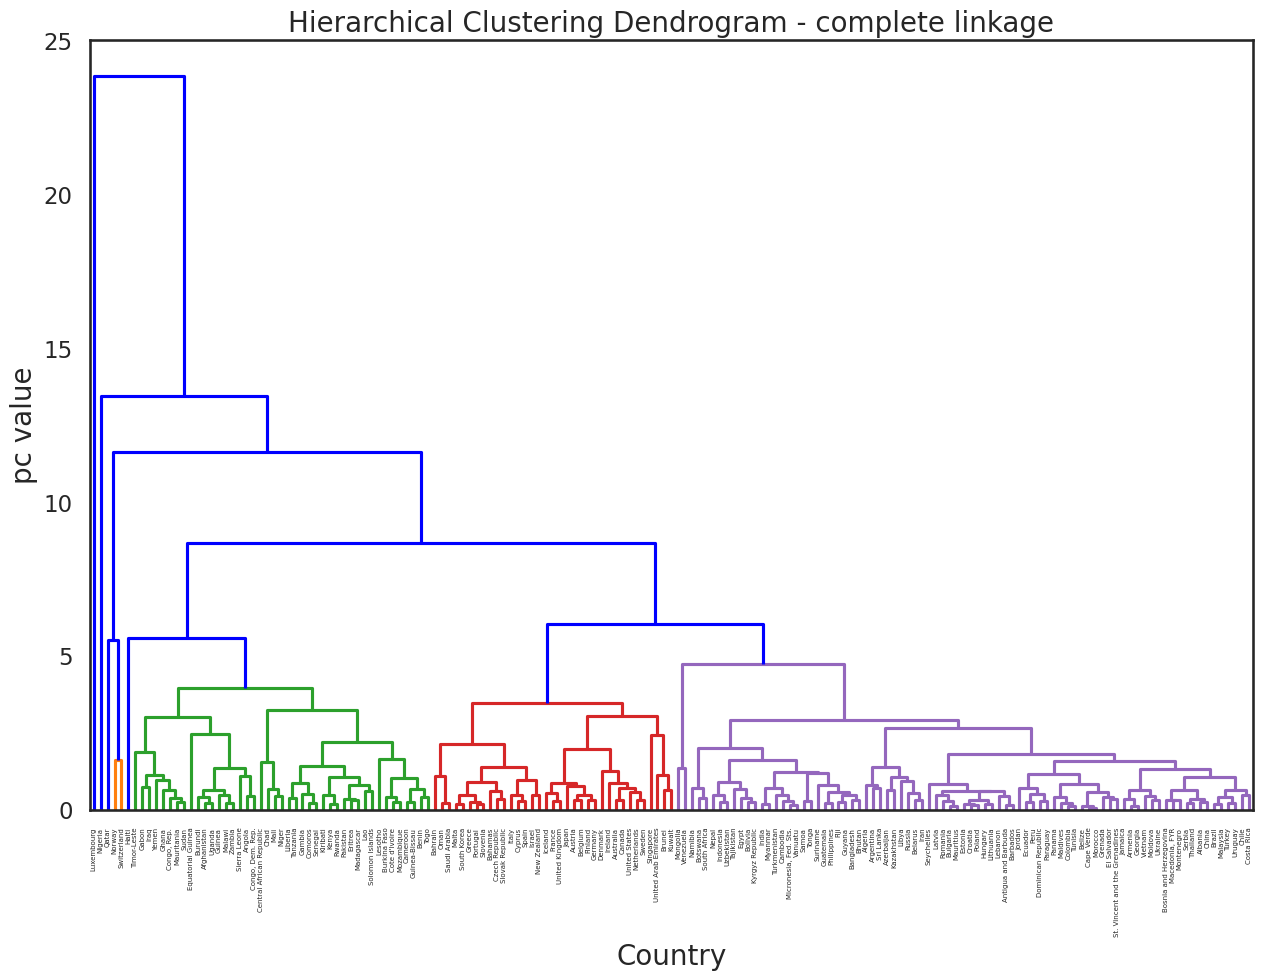

In [43]:
# Complete linkage

# setting the figure and graph style

plt.figure(figsize=(15,10))                                                                             # Setting the size of the figure
sns.set_style('white')                                                                                  # Setting style

# setting the labels on axes and title

plt.title('Hierarchical Clustering Dendrogram - complete linkage',fontsize=20)
plt.xlabel('Country',fontsize=20)
plt.ylabel('pc value',fontsize=20)


complete_linkage = linkage(hier_cluster_pca, method='complete', metric='euclidean')                             # complete linkage
dendrogram(complete_linkage,above_threshold_color='blue',color_threshold=5.5,labels=hier_cluster_pca.index) # creating dendrogram

plt.show()                                                                                              # plot showing

In [44]:
# Applying 4 clusters

cluster_label=cut_tree(complete_linkage,n_clusters=4).reshape(-1, )  # using cut_tree for selecting number of clusters

cluster_label

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [45]:
# Asssigning the cluster labels to the dataset

hier_cluster_pca['Cluster_label']=cluster_label

hier_cluster_pca.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,Cluster_label
country,,,,,,
Afghanistan,-2.369574,1.700240,-0.392913,0.500420,0.188538,0
Albania,0.170985,-1.090922,-0.254308,-0.815335,0.008727,0
Algeria,-0.245200,-0.461146,0.811643,-0.582408,0.323965,0
Angola,-2.534706,2.155072,0.850696,0.713157,0.317229,0
Antigua and Barbuda,0.563002,-1.085921,-0.362891,-0.245699,0.063558,0


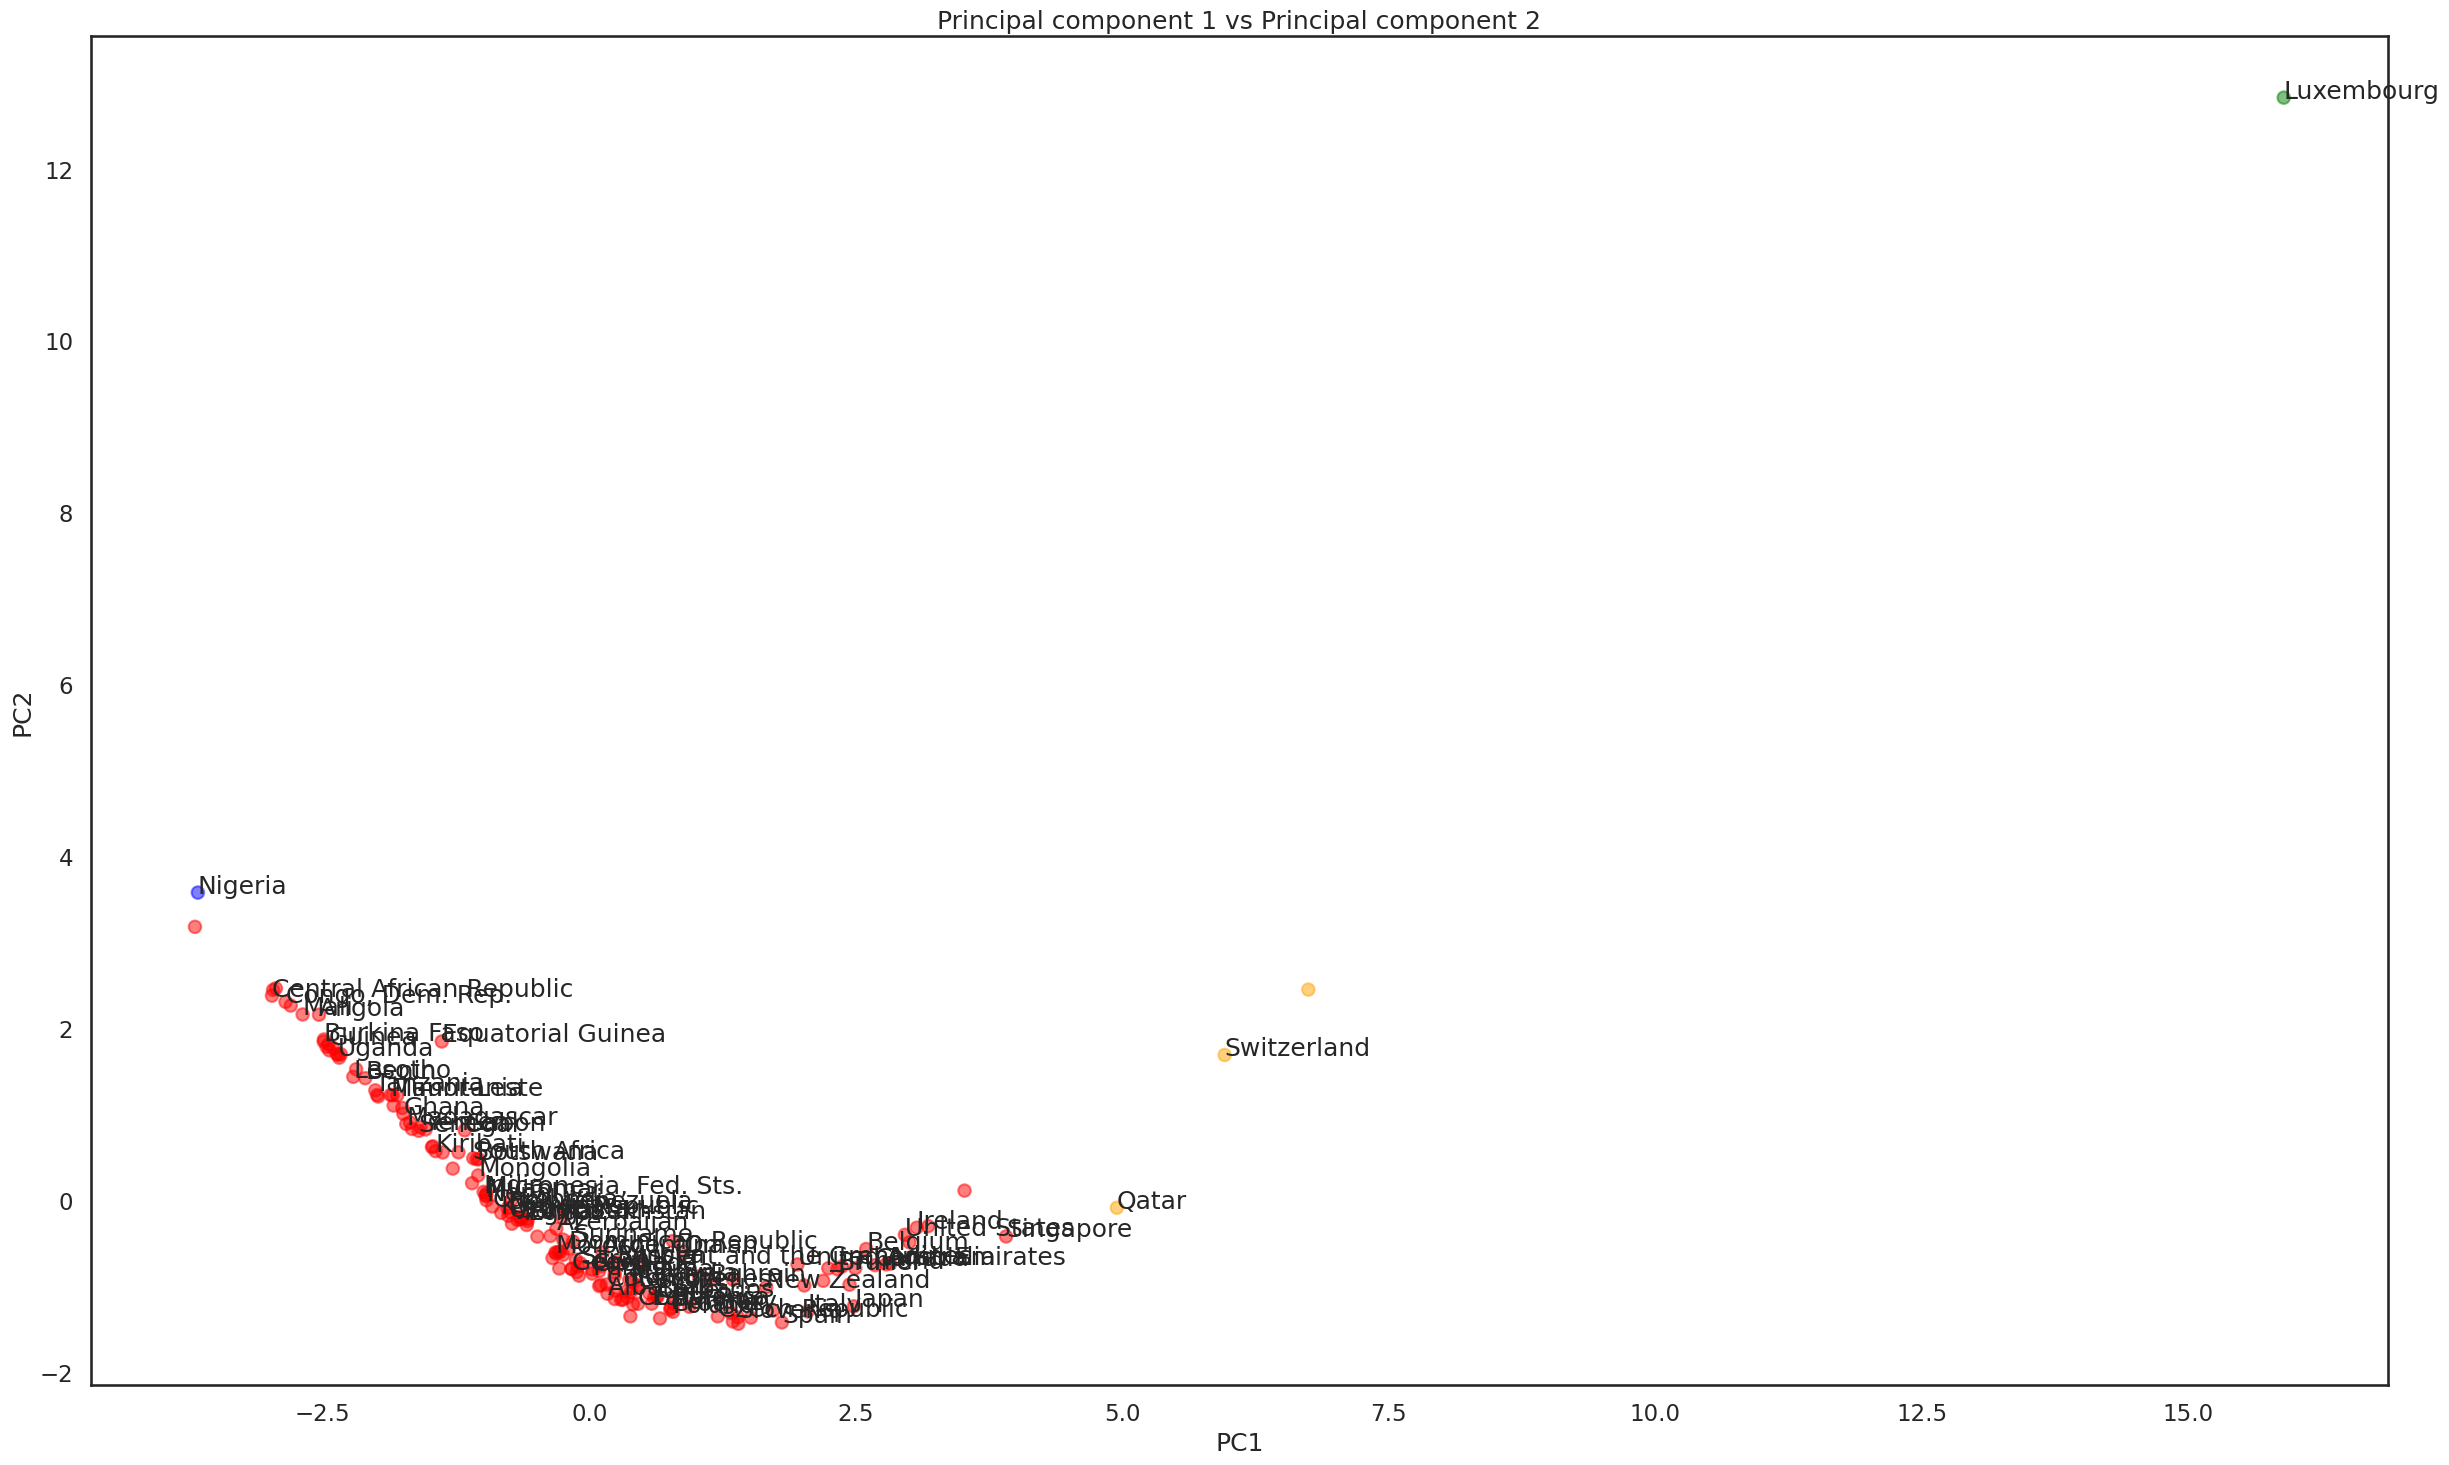

In [46]:
# Visualising the clusters formed by choosing first two pricipal components(on X-Y axes)
%matplotlib inline
sns.set_style('white')
sns.set_context('talk')

fig = plt.figure(figsize = (25,15))   # setting the figure size

# setting title

plt.title("Principal component 1 vs Principal component 2")

# Plotting a scatter plot

plt.scatter(hier_cluster_pca['PC_1'] , hier_cluster_pca['PC_2'] ,
            c = hier_cluster_pca.Cluster_label.map({0:'red',1:'green',2:'blue',3:'orange'}), alpha = 0.5)

# labeling different cluster points with country names
for i, txt in enumerate(hier_cluster_pca.index):
    if i%2:
        plt.annotate(txt, (hier_cluster_pca.PC_1[i],hier_cluster_pca.PC_2[i]))

# labeling the axes

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()   # changing the layout
plt.show()           # Showing the plot

In [48]:
# Analysing cluster by comparing [gdpp,child_mort and income] - how they vary in hierarchical clustering

df_country_hier= df_country.drop('Cluster_id', axis=1)  # Use axis=1 to specify dropping a column
# Imputing the new hierarchical clusters in the dataset

df_country_hier['Cluster_level'] = cluster_label

df_country_hier.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_level
country,,,,,,,,,,
Afghanistan,90.2,1.691124e+03,1.281872e+03,7.593146e+03,1610,9.44,56.2,5.82,553,0
Albania,16.6,1.915702e+06,4.481374e+05,3.325111e+06,9930,4.49,76.3,1.65,4090,0
Algeria,27.3,3.406715e+06,3.699480e+05,2.785699e+06,12900,16.10,76.5,2.89,4460,0
Angola,119.0,2.740389e+06,1.253629e+05,1.887041e+06,5900,22.40,60.1,6.16,3530,0
Antigua and Barbuda,10.3,8.262108e+07,1.094956e+07,1.069534e+08,19100,1.44,76.8,2.13,12200,0


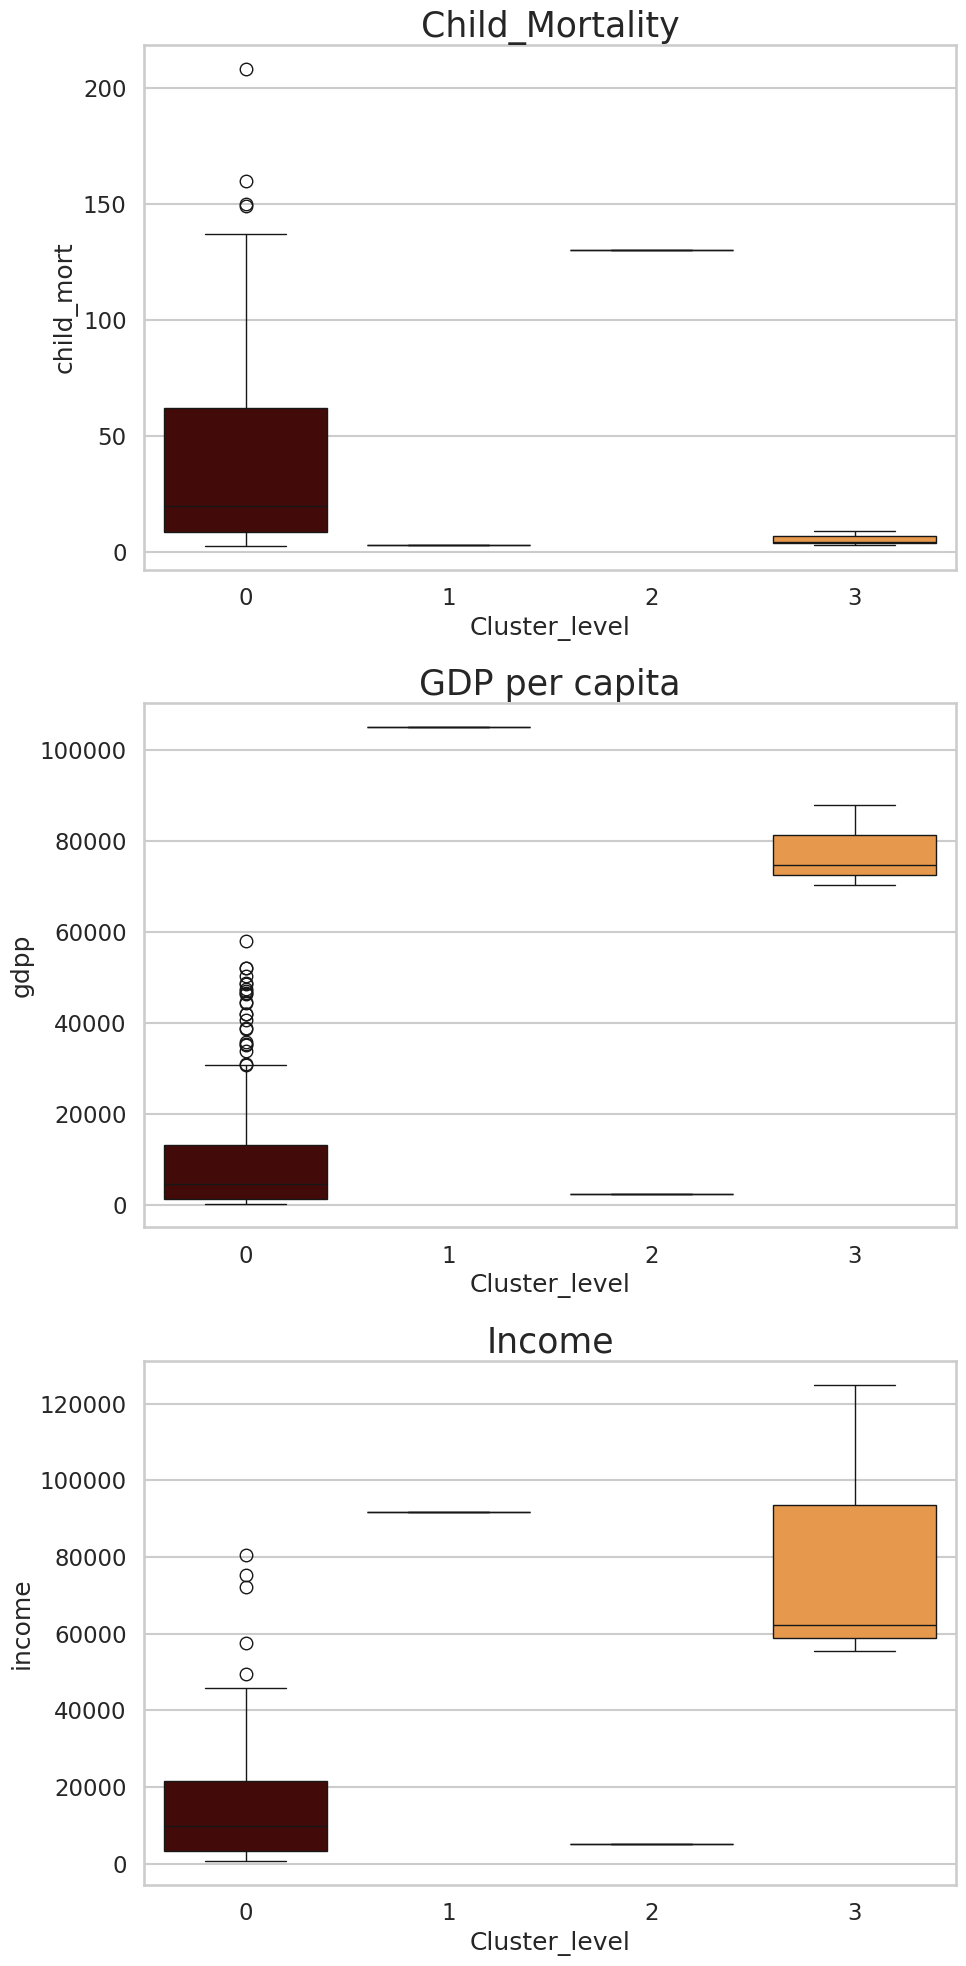

In [49]:
# Setting size of figure, context and gridlines

plt.figure(figsize=(10,20))
plt.tight_layout()
sns.set_style('whitegrid')
sns.set_context('talk')


# Visualising the outliers with boxplot for child_mort, income and gdpp variables

plt.subplot(3,1,1)                          # creating subplots
plt.title('Child_Mortality',fontsize=25)   # giving title with font size

# creating boxplot

sns.boxplot(x='Cluster_level',y='child_mort',data=df_country_hier,palette='gist_heat',orient='v')

plt.subplot(3,1,2)                          # creating subplots
plt.title('GDP per capita',fontsize=25)   # giving title with font size

# creating boxplot

sns.boxplot(x='Cluster_level',y='gdpp',data=df_country_hier,palette='gist_heat',orient='v')

plt.subplot(3,1,3)                          # creating subplots
plt.title('Income',fontsize=25)   # giving title with font size

# creating boxplot

sns.boxplot(x='Cluster_level',y='income',data=df_country_hier,palette='gist_heat',orient='v')

plt.tight_layout()

Valuable Insights from above three boxplots :

For cluster 0: gdpp and income is lower than other clusters, Mortality of children is very high than other clusters.
For cluster 1: Behaving normally in all departments(income, gdpp and children mortality) except for some outliers.
For cluster 2: gdpp and income is higher than other clusters, Mortality of children is very less compared to other clusters.
For cluster 3: gdpp and income is extremely low and child_mort is very high. Countries belonging to this cluster require serious aid

In [50]:
# Finding the no. of countries that require serious aid (cluster 3)

Country_urg_help_hier= pd.DataFrame(hier_cluster_pca[hier_cluster_pca['Cluster_label']==3].index)

Country_urg_help_hier

,country
0,Norway
1,Qatar
2,Switzerland


In [51]:
# Finding the no. of countries that require help (cluster 0)

Country_help_hier= pd.DataFrame(hier_cluster_pca[hier_cluster_pca['Cluster_label']==0].index)

Country_help_hier.shape

(162, 1)

In [52]:
# Finding the no. of countries that require no help (cluster 2)

Country_nohelp_hier= pd.DataFrame(hier_cluster_pca[hier_cluster_pca['Cluster_label']==2].index)

Country_nohelp_hier

,country
0,Nigeria


In [53]:
#There are 144 countries found from the hierarchical analysis in need of urgent help/aid as it is having lowest income, high child mortality and low gdp per capita. There is 1 country Nigeria that requires serious and urgent attention

K-means vs Heirarchical Clustering


**K-means clustering :**
Countries that are direst need of aid
Total 48 countries are in this category where it looks like Nigeria needs most help
Countries that are having good socio-economic and health factors
Total 1 countries are in this category - Luxembourg
Countries having bad socio-economic and some existing healthcare infrastructure that may or may not require help
Total 30 countries are in this category


**Hierarchical clustering :**

Countries that are direst need of aid
Total 144 countries are in this category in which Nigeria is need of most help.
Countries that are having good socio-economic and health factors
1 country is in this category - Luxembourg
We have seen from both methods - (K-Means and Hierarchical clustering) that extra 96 countries are being selected from hierarchical clustering. I would choose the final countries from k-means clustering as it gave accurate output than hierarchical clustering.